### 1. Import Libraries

In [27]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from prophet import Prophet
from sklearn.metrics import mean_absolute_error, mean_squared_error

### 2. Load and Prepare Data

In [28]:
energy_hourly = pd.read_csv('../data/processed/energy_hourly.csv', index_col=0, parse_dates=True)
energy_hourly.head()

,Global_active_power
datetime,
2006-12-16 17:00:00,4.222889
2006-12-16 18:00:00,3.632200
2006-12-16 19:00:00,3.400233
2006-12-16 20:00:00,3.268567
2006-12-16 21:00:00,3.056467


### 3. Data Formatting for Prophet

In [29]:
prophet_df = energy_hourly.reset_index()
prophet_df.columns = ['ds', 'y']

prophet_df

,ds,y
0,2006-12-16 17:00:00,4.222889
1,2006-12-16 18:00:00,3.632200
2,2006-12-16 19:00:00,3.400233
3,2006-12-16 20:00:00,3.268567
4,2006-12-16 21:00:00,3.056467
...,...,...
34584,2010-11-26 17:00:00,1.725900
34585,2010-11-26 18:00:00,1.573467
34586,2010-11-26 19:00:00,1.659333
34587,2010-11-26 20:00:00,1.163700


### 4. Train-Test Split

In [30]:
train_size = int(len(prophet_df) * 0.9)

train = prophet_df[:train_size]
test = prophet_df[train_size:]

### 5. Prophet Model Training

Prophet is used to model time series data with strong seasonality and trend components. It automatically handles daily and weekly seasonality.

In [31]:
model = Prophet(
    daily_seasonality=True,
    weekly_seasonality=True
)

model.fit(train)

11:46:26 - cmdstanpy - INFO - Chain [1] start processing
11:46:31 - cmdstanpy - INFO - Chain [1] done processing


### 6. Forecast Generation

In [32]:
future = model.make_future_dataframe(periods=len(test), freq='h')
forecast = model.predict(future)
forecast

,ds,trend,yhat_lower,yhat_upper,trend_lower,trend_upper,additive_terms,additive_terms_lower,additive_terms_upper,daily,...,weekly,weekly_lower,weekly_upper,yearly,yearly_lower,yearly_upper,multiplicative_terms,multiplicative_terms_lower,multiplicative_terms_upper,yhat
0,2006-12-16 17:00:00,1.396629,0.822342,2.771101,1.396629,1.396629,0.394440,0.394440,0.394440,-0.075799,...,0.170846,0.170846,0.170846,0.299392,0.299392,0.299392,0.0,0.0,0.0,1.791069
1,2006-12-16 18:00:00,1.396498,1.223099,3.097417,1.396498,1.396498,0.756484,0.756484,0.756484,0.278552,...,0.178289,0.178289,0.178289,0.299644,0.299644,0.299644,0.0,0.0,0.0,2.152982
2,2006-12-16 19:00:00,1.396368,1.645276,3.451153,1.396368,1.396368,1.170616,1.170616,1.170616,0.685619,...,0.185101,0.185101,0.185101,0.299896,0.299896,0.299896,0.0,0.0,0.0,2.566984
3,2006-12-16 20:00:00,1.396237,1.821820,3.707721,1.396237,1.396237,1.370203,1.370203,1.370203,0.878829,...,0.191224,0.191224,0.191224,0.300150,0.300150,0.300150,0.0,0.0,0.0,2.766440
4,2006-12-16 21:00:00,1.396107,1.628129,3.475919,1.396107,1.396107,1.217066,1.217066,1.217066,0.720056,...,0.196605,0.196605,0.196605,0.300405,0.300405,0.300405,0.0,0.0,0.0,2.613173
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
34584,2010-11-26 17:00:00,1.125882,0.432658,2.343252,1.076417,1.182373,0.255402,0.255402,0.255402,-0.075799,...,-0.045306,-0.045306,-0.045306,0.376507,0.376507,0.376507,0.0,0.0,0.0,1.381283
34585,2010-11-26 18:00:00,1.125886,0.805134,2.743813,1.076400,1.182416,0.616039,0.616039,0.616039,0.278552,...,-0.038883,-0.038883,-0.038883,0.376371,0.376371,0.376371,0.0,0.0,0.0,1.741925
34586,2010-11-26 19:00:00,1.125891,1.274559,3.115851,1.076383,1.182459,1.029779,1.029779,1.029779,0.685619,...,-0.032072,-0.032072,-0.032072,0.376231,0.376231,0.376231,0.0,0.0,0.0,2.155669
34587,2010-11-26 20:00:00,1.125895,1.451615,3.275506,1.076366,1.182502,1.230046,1.230046,1.230046,0.878829,...,-0.024872,-0.024872,-0.024872,0.376088,0.376088,0.376088,0.0,0.0,0.0,2.355941


- yhat → prediction
- yhat_lower → lower bound
- yhat_upper → upper bound

### 7. Forecast Visualization

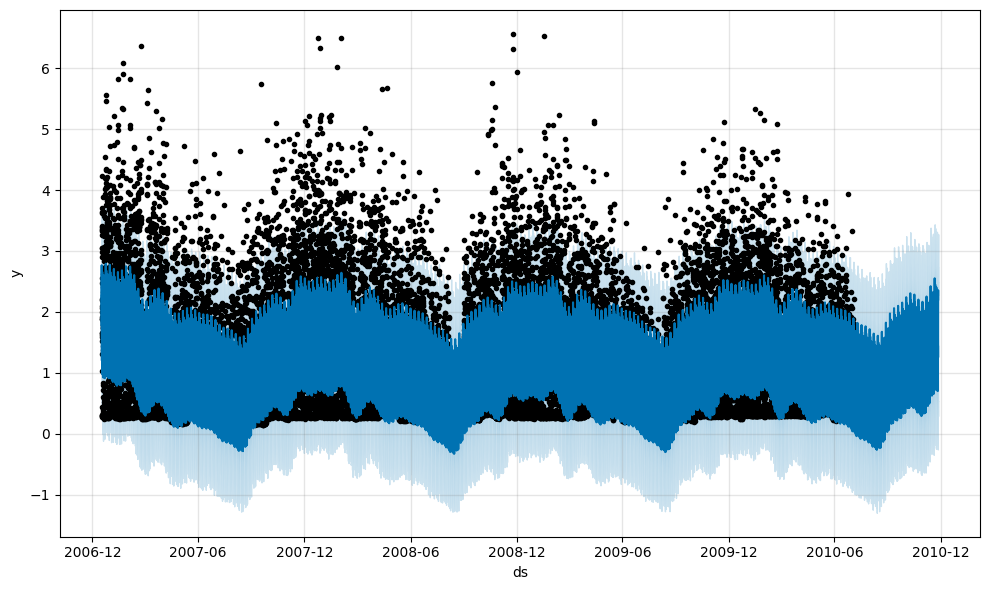

In [33]:
model.plot(forecast); 

- Black dots → actual
- Blue line → prediction
- Light blue → confidence interval

### 8. Components Analysis (Trend & Seasonality)

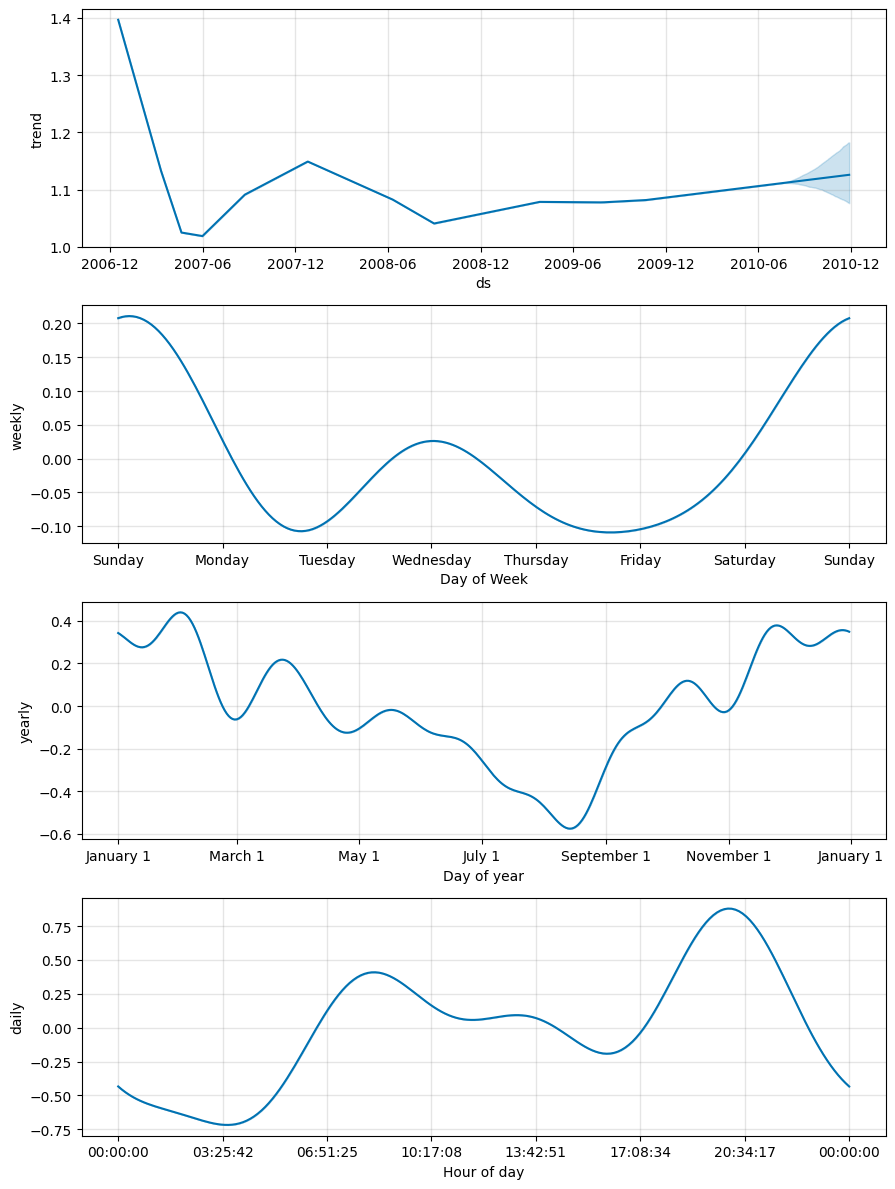

In [34]:
model.plot_components(forecast);

### 9. Model Evaluation Strategy

- The model is evaluated using a train-test split (90%-10%).  
- Performance is measured using MAE, RMSE, and MAPE.  
- A 24-hour forecast is also generated for short-term evaluation.

### 10. Model Evaluation (MAE, RMSE, MAPE)

In [35]:
forecast_test = forecast.iloc[-len(test):]

mae = mean_absolute_error(test['y'], forecast_test['yhat'])
rmse = np.sqrt(mean_squared_error(test['y'], forecast_test['yhat']))

print("MAE :", mae)
print("RMSE:", rmse)

def mape(y_true, y_pred):
    return (abs((y_true - y_pred) / y_true).mean()) * 100

mape_value = mape(test['y'], forecast_test['yhat'])
print("MAPE:", mape_value)

MAE : 0.49456349999508314
RMSE: 0.6399011808375922
MAPE: 82.3886291009464


The Prophet model was evaluated using MAE and RMSE.

- MAE measures average error magnitude
- RMSE penalizes larger errors more heavily
- MAPE provides a percentage-based error metric for better interpretability.

The results indicate that the model captures overall trends and seasonality effectively.

### 12. Prediction Interval Coverage

Prediction interval coverage measures how often the actual values fall within the predicted confidence interval.

A higher coverage indicates that the model provides reliable uncertainty estimates.

In [36]:
coverage = ((test['y'] >= forecast_test['yhat_lower']) & 
            (test['y'] <= forecast_test['yhat_upper'])).mean()

print("Prediction Interval Coverage:", coverage)

Prediction Interval Coverage: 0.8699045967042498


### 13. Final Forecast vs Actual

The following plot compares the model predictions with actual values on the test dataset.

This helps visually assess how well the model captures real-world patterns.

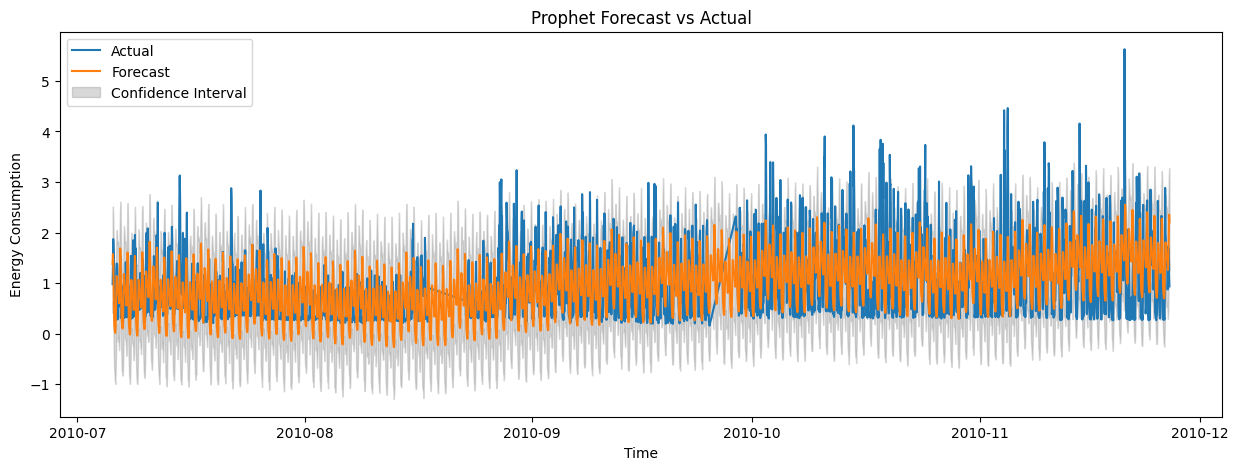

In [37]:
plt.figure(figsize=(15,5))

plt.plot(test['ds'], test['y'], label='Actual')
plt.plot(test['ds'], forecast_test['yhat'], label='Forecast')

plt.fill_between(
    test['ds'],
    forecast_test['yhat_lower'],
    forecast_test['yhat_upper'],
    color='gray',
    alpha=0.3,
    label='Confidence Interval'
)

plt.legend()
plt.title('Prophet Forecast vs Actual')
plt.xlabel('Time')
plt.ylabel('Energy Consumption')

plt.show()

### 14. Hyperparameter Tuning

- Hyperparameter tuning was performed to improve model performance by adjusting key parameters of the Prophet model.
- The parameter `changepoint_prior_scale` controls the flexibility of the trend. A higher value allows the model to adapt more quickly to changes in the data.

In [38]:
# Default model (already trained earlier)
mae_default = mae
rmse_default = rmse

# Tuned model
model_tuned = Prophet(
    daily_seasonality=True,
    weekly_seasonality=True,
    changepoint_prior_scale=0.5
)

model_tuned.fit(train)

future = model_tuned.make_future_dataframe(periods=len(test), freq='h')
forecast_tuned = model_tuned.predict(future)

forecast_test_tuned = forecast_tuned.iloc[-len(test):]

mae_tuned = mean_absolute_error(test['y'], forecast_test_tuned['yhat'])
rmse_tuned = np.sqrt(mean_squared_error(test['y'], forecast_test_tuned['yhat']))

print("Default MAE :", mae_default)
print("Tuned MAE   :", mae_tuned)

print("Default RMSE:", rmse_default)
print("Tuned RMSE  :", rmse_tuned)

11:46:37 - cmdstanpy - INFO - Chain [1] start processing
11:46:46 - cmdstanpy - INFO - Chain [1] done processing


Default MAE : 0.49456349999508314
Tuned MAE   : 0.4984589676144016
Default RMSE: 0.6399011808375922
Tuned RMSE  : 0.6417721621325545


### Hyperparameter Tuning Results

The tuned model was compared with the default configuration.

- Default MAE: 0.494  
- Tuned MAE: 0.498  
- Default RMSE: 0.639  
- Tuned RMSE: 0.641 

The tuned model showed slightly higher error compared to the default configuration.

This indicates that the default Prophet parameters are already well-suited for this dataset and provide better generalization.

This experiment highlights that hyperparameter tuning does not always guarantee improved performance and must be validated using proper evaluation metrics.

Prophet’s default configuration is often robust for datasets with clear seasonality, reducing the need for extensive tuning.

### 15. Residual Analysis

- Residuals appear randomly distributed around zero, indicating that the model has captured most of the underlying patterns in the data.
- No clear patterns or trends are observed, suggesting good model performance.

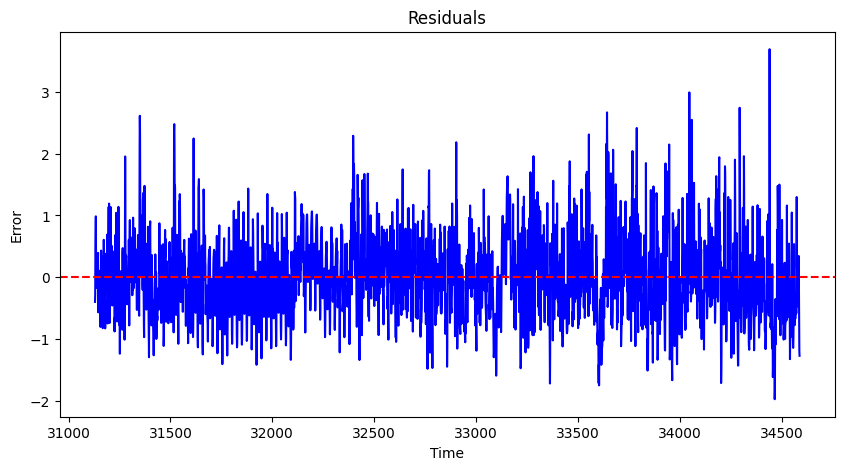

In [ ]:
residuals = test['y'] - forecast_test['yhat']

plt.figure(figsize=(10,5))
plt.plot(residuals, color='blue')

plt.axhline(0, color='red', linestyle='--')

plt.title('Residuals')
plt.xlabel('Time')
plt.ylabel('Error')

plt.show()

### 16. Walk-Forward Validation

A simple walk-forward validation approach was implemented by training the model on historical data and forecasting the next 24 hours.

This helps evaluate how well the model generalizes to unseen future data.

In [40]:
train_small = prophet_df[:-24]
test_small = prophet_df[-24:]

model = Prophet(daily_seasonality=True, weekly_seasonality=True)
model.fit(train_small)

future = model.make_future_dataframe(periods=24, freq='h')
forecast = model.predict(future)

pred = forecast[['ds','yhat']].tail(24)

mae_wf = mean_absolute_error(test_small['y'], pred['yhat'])
print("Walk-forward MAE:", mae_wf)

11:46:51 - cmdstanpy - INFO - Chain [1] start processing
11:46:56 - cmdstanpy - INFO - Chain [1] done processing


Walk-forward MAE: 0.39589413103617854


In [41]:
forecast[['ds', 'yhat', 'yhat_lower', 'yhat_upper']].tail(24)

,ds,yhat,yhat_lower,yhat_upper
34565,2010-11-25 22:00:00,1.618100,0.652609,2.507916
34566,2010-11-25 23:00:00,1.191629,0.148701,2.133099
34567,2010-11-26 00:00:00,0.911721,-0.020444,1.840488
34568,2010-11-26 01:00:00,0.786547,-0.139931,1.696884
34569,2010-11-26 02:00:00,0.718905,-0.197398,1.625708
34570,2010-11-26 03:00:00,0.652592,-0.309398,1.591570
34571,2010-11-26 04:00:00,0.647675,-0.376190,1.519902
34572,2010-11-26 05:00:00,0.807853,-0.140601,1.682560
34573,2010-11-26 06:00:00,1.141420,0.184919,2.014780
34574,2010-11-26 07:00:00,1.508796,0.548335,2.452186


### 17. 24-Hour Forecast Output

In [42]:
future_24 = model.make_future_dataframe(periods=24, freq='h')
forecast_24 = model.predict(future_24)

forecast_24[['ds', 'yhat', 'yhat_lower', 'yhat_upper']].tail(24)

,ds,yhat,yhat_lower,yhat_upper
34565,2010-11-25 22:00:00,1.618100,0.664620,2.618162
34566,2010-11-25 23:00:00,1.191629,0.260209,2.117906
34567,2010-11-26 00:00:00,0.911721,-0.026436,1.850068
34568,2010-11-26 01:00:00,0.786547,-0.134003,1.761474
34569,2010-11-26 02:00:00,0.718905,-0.182856,1.647183
34570,2010-11-26 03:00:00,0.652592,-0.273320,1.519238
34571,2010-11-26 04:00:00,0.647675,-0.225302,1.557443
34572,2010-11-26 05:00:00,0.807853,-0.108034,1.729646
34573,2010-11-26 06:00:00,1.141420,0.157968,2.054081
34574,2010-11-26 07:00:00,1.508796,0.589074,2.470590


### 18. Key Observations

- Prophet effectively captures daily and weekly seasonality.
- The model provides uncertainty intervals, which are useful for decision-making.
- Forecasts align well with historical trends.